In [16]:
import numpy as np
from matplotlib import pyplot as plt
import cv2

## Lab 3: Image clustering and superpixels

In this lab we are going to explore image clustering and superpixels segmentation. You will be required to complete the following tasks:

1. Implement k-means clustering to assign each pixel of an image to one of K distinct clusters, using colour similarity to determine assignment.
2. Modify your k-means clustering to find superpixels by assigning each pixel of the image to one of K distinct clusters, using both colour and location similarity to determine assignment.
3. Use superpixels to propose regions of interest in the image (we will learn about neural networks that use this information in week 11). 
4. Write a brief report (max 600 words) discussing explaining your implementation and results. Explain your reasoning by referencing the intermediate result figures you generated. 

You may use numpy and matplotlib and opencv for image loading.

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

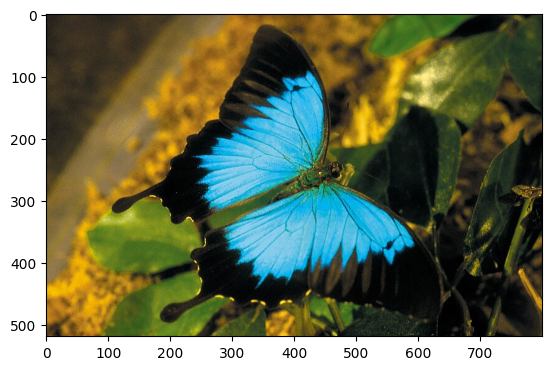

In [17]:
# Load and display image for testing
im = cv2.imread('CSIRO_ScienceImage_3831_Ulysses_Butterfly.jpg')
plt.imshow(im[:,:,[2,1,0]])
plt.show()

### Task 1: Implement K-means from first principles: colour similarity

Fill in the function below to implement the following steps. Your function should accept an image, a variable storing the number of iterations to repeat k-means for, the number of clusters K.
1. Flatten the image into an Nx3 vector of pixels (num pixels x r,g,b colour of pixel)
2. Select K random colour centroids
3. Repeat for n iterations:
   1. Assign each pixel in the vector to a cluster and store the index corresponding to this in a numpy array
   2. Update the centroid locations using the new cluster assignments
   3. Save the total loss at each iteration
4. Convert the cluster index array back into a 2D array the same size as the image, where each pixel contains the corresponding cluster index
5. Create a new quantised image, where each pixel is coloured according to the centroid corresponding to a given cluster index.
6. Return the loss, cluster index image and quantised image
7. Test your function on the sample image provided, and select an appropriate number of iterations 
8. Display the results for a number of choices of K. Use the returned losses to select an appropriate value for K 

In [18]:
def kmeans(im, iters=2, K=3, plot=False):

    # Kmeans is stochastic, so we will fix the seed of the random number generator to ensure each iteration starts with the same centroid initialisation
    seed = 42
    np.random.seed(seed)

    # Convert image into an Nx3 vector of pixels
    im_vector = np.reshape(im, [-1, 3]) / 255

    # Select K random colour centroids
    centroids = im_vector[np.random.choice(im_vector.shape[0], K, replace = False)]

    im_row = len(im)
    im_col = len(im[0])

    for j in range(1,iters):

        # Creates array of pixels of size (pixels, centroids)
        dists = np.linalg.norm(im_vector[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)

        # Return minimum value for each row of dists
        cluster_indices = np.argmin(dists, axis=1)

        # Clear centroid list
        centroids = []
        for i in range(K):
            # gets boolean that provides 1 if nearest centroid is i
            target_centroid = cluster_indices == i

            # Takes the mean of im_vector using only the pixels closest to centroid i
            if target_centroid.sum() > 0:
                # Gets an array of just the pixels within the current centroid cluster
                pixels = im_vector[target_centroid]
                mean_centroid = im_vector[target_centroid].mean(axis=0)

                # Finds the closest pixel to the mean
                closest_dist = np.linalg.norm(pixels - mean_centroid, axis=1)
                closest_idx = np.argmin(closest_dist)

            centroids.append(pixels[closest_idx])
        centroids = np.array(centroids)

        # Store the current loss
        loss = 0
        for point in range(im_vector.shape[0]):
            # Distance between centroids[cluster_indices[point]] and im_vector[point]
            loss += np.linalg.norm(centroids[cluster_indices[point]] - im_vector[point])**2

    # Convert cluster indices to an image
    cluster_idx_image = np.zeros((im_row, im_col))

    for k in range(im_col):
        for i in range(im_row):
            cluster_idx_image[i][k] = cluster_indices[i*im_col + k]


    # Get array of centroids RGB values
    centroid_rgb = np.array(centroids)[:, :3] * 255
    # Swap first and third rgb values
    centroid_rgb[:, 0] = np.array(centroids)[:, 2] * 255
    centroid_rgb[:, 2] = np.array(centroids)[:, 0] * 255

    quantised_image = centroid_rgb[cluster_indices].reshape(im_row, im_col, 3).astype(np.uint8)

    # You may want to visualise the current progress of kmeans for debugging purposes
    plt.subplot(1,2,1)
    plt.imshow(cluster_idx_image)
    plt.subplot(1,2,2)
    plt.imshow(quantised_image)
    plt.show()

    return loss, cluster_idx_image, quantised_image


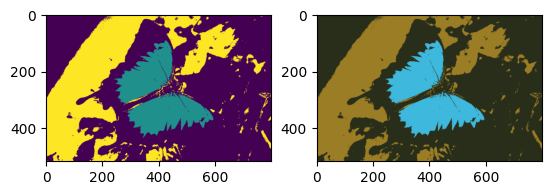

(np.float64(14428.797477890681),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(519, 800)),
 array([[[41, 46, 26],
         [41, 46, 26],
         [41, 46, 26],
         ...,
         [41, 46, 26],
         [41, 46, 26],
         [41, 46, 26]],
 
        [[41, 46, 26],
         [41, 46, 26],
         [41, 46, 26],
         ...,
         [41, 46, 26],
         [41, 46, 26],
         [41, 46, 26]],
 
        [[41, 46, 26],
         [41, 46, 26],
         [41, 46, 26],
         ...,
         [41, 46, 26],
         [41, 46, 26],
         [41, 46, 26]],
 
        ...,
 
        [[41, 46, 26],
         [41, 46, 26],
         [41, 46, 26],
         ...,
         [41, 46, 26],
         [41, 46, 26],
         [41, 46, 26]],
 
        [[41, 46, 26],
         [41, 46, 26],
         [41, 46, 2

In [19]:
# Test your function using the image provided
kmeans(im)

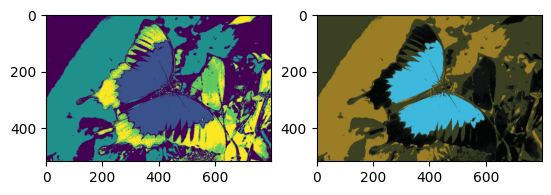

(np.float64(9478.526566700682),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(519, 800)),
 array([[[59, 64, 34],
         [59, 64, 34],
         [59, 64, 34],
         ...,
         [59, 64, 34],
         [59, 64, 34],
         [59, 64, 34]],
 
        [[59, 64, 34],
         [59, 64, 34],
         [59, 64, 34],
         ...,
         [59, 64, 34],
         [59, 64, 34],
         [59, 64, 34]],
 
        [[59, 64, 34],
         [59, 64, 34],
         [59, 64, 34],
         ...,
         [59, 64, 34],
         [59, 64, 34],
         [59, 64, 34]],
 
        ...,
 
        [[59, 64, 34],
         [59, 64, 34],
         [59, 64, 34],
         ...,
         [59, 64, 34],
         [59, 64, 34],
         [59, 64, 34]],
 
        [[59, 64, 34],
         [59, 64, 34],
         [59, 64, 34

In [20]:
# Select an appropriate value for K and use visualisations to show how you did this
kmeans(im, 2, 5, False)

### Task 2: Modify K-means to cluster based on colour similarity and pixel location and extract superpixels

1. Modify the k_means function above to segment based on colour and pixel location, so that you extract superpixels.

2. Test your implementation by clustering the image into 50 superpixels.

3. Select an appropriate pixel coordinate scaling factor so that you trade-off incorporating colour information into the clustering, while ensuring superpixel continuity (all pixels in a superpixel must remain connected).

In [21]:
# Use your kmeans function to cluster based on colour and location
def kmean_colour(im, iters=2, K=3, plot=False, spatial_weight = 1):

    # Kmeans is stochastic, so we will fix the seed of the random number generator to ensure each iteration starts with the same centroid initialisation
    seed = 42
    np.random.seed(seed)

    # Convert image into an Nx3 vector of pixels
    im_vector = np.reshape(im, [-1, 3]) /255

    im_row = len(im)
    im_col = len(im[0])

    # Build coordinate grid
    rows, cols = np.indices((im_row, im_col))
    x_coords = rows.reshape(-1, 1) / im_row    # normalise 0-1
    y_coords = cols.reshape(-1, 1) / im_col    # normalise 0-1

    # Normalise colours to 0-1 as well so scales match
    colour_vector = im_vector

    im_vector = np.hstack([colour_vector, x_coords * spatial_weight, y_coords * spatial_weight])

    # Select K random colour centroids
    centroids = im_vector[np.random.choice(im_vector.shape[0], K, replace = False)]

    centroids = np.array(centroids[:K])

    for j in range(1,iters):
        # Creates array of pixels of size (pixels, centroids)
        dists = np.linalg.norm(im_vector[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)

        # Return minimum value for each row of dists
        cluster_indices = np.argmin(dists, axis=1)

        # Clear centroid list
        centroids = []
        for i in range(K):
            # gets boolean that provides 1 if nearest centroid is i
            target_centroid = cluster_indices == i

            # Takes the mean of im_vector using only the pixels closest to centroid i
            if target_centroid.sum() > 0:
                # Gets an array of just the pixels within the current centroid cluster
                pixels = im_vector[target_centroid]
                mean_centroid = im_vector[target_centroid].mean(axis=0)

                # Finds the closest pixel to the mean
                closest_dist = np.linalg.norm(pixels - mean_centroid, axis=1)
                closest_idx = np.argmin(closest_dist)

            centroids.append(pixels[closest_idx])
        centroids = np.array(centroids)

        # Store the current loss
        loss = 0
        for point in range(im_vector.shape[0]):
            #distance between centroids[cluster_indices[point]] and im_vector[point]
            loss += np.linalg.norm(centroids[cluster_indices[point]] - im_vector[point])**2

    # Convert cluster indices to an image
    cluster_idx_image = cluster_indices.reshape(im_row, im_col)

    # Get array of centroids RGB values
    centroid_rgb = np.array(centroids)[:, :3] * 255
    # Swap first and third rgb values
    centroid_rgb[:, 0] = np.array(centroids)[:, 2] * 255
    centroid_rgb[:, 1] = np.array(centroids)[:, 1] * 255
    centroid_rgb[:, 2] = np.array(centroids)[:, 0] * 255

    quantised_image = centroid_rgb[cluster_indices].reshape(im_row, im_col, 3).astype(np.uint8)


    # You may want to visualise the current progress of kmeans for debugging purposes
    plt.subplot(1,2,1)
    plt.imshow(cluster_idx_image)
    plt.subplot(1,2,2)
    plt.imshow(quantised_image)
    plt.show()

    return loss, cluster_idx_image, quantised_image

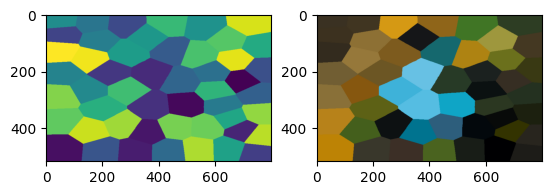

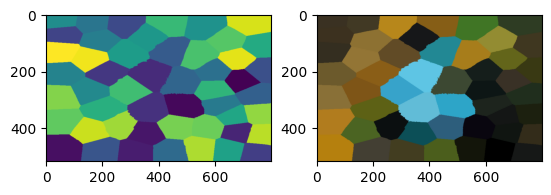

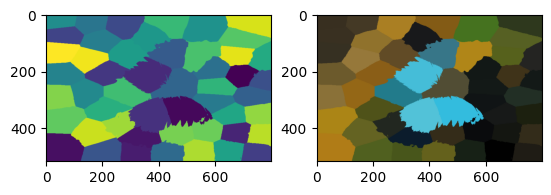

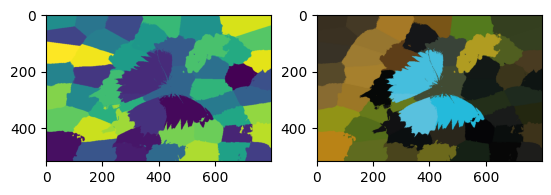

(np.float64(59244.82373580016),
 array([[24, 24, 24, ..., 46, 46, 46],
        [24, 24, 24, ..., 46, 46, 46],
        [24, 24, 24, ..., 46, 46, 46],
        ...,
        [ 2,  2,  2, ...,  9,  9,  9],
        [ 2,  2,  2, ...,  9,  9,  9],
        [ 2,  2,  2, ...,  9,  9,  9]], shape=(519, 800)),
 array([[[ 56,  47,  32],
         [ 56,  47,  32],
         [ 56,  47,  32],
         ...,
         [ 52,  63,  31],
         [ 52,  63,  31],
         [ 52,  63,  31]],
 
        [[ 56,  47,  32],
         [ 56,  47,  32],
         [ 56,  47,  32],
         ...,
         [ 52,  63,  31],
         [ 52,  63,  31],
         [ 52,  63,  31]],
 
        [[ 56,  47,  32],
         [ 56,  47,  32],
         [ 56,  47,  32],
         ...,
         [ 52,  63,  31],
         [ 52,  63,  31],
         [ 52,  63,  31]],
 
        ...,
 
        [[185, 131,  22],
         [185, 131,  22],
         [185, 131,  22],
         ...,
         [ 29,  29,  27],
         [ 29,  29,  27],
         [ 29,  29,  27

In [22]:
# Visualise your superpixel clustering for different scaling parameters
kmean_colour(im, 10, 50, False, 50)
kmean_colour(im, 10, 50, False, 20)
kmean_colour(im, 10, 50, False, 10)
kmean_colour(im, 10, 50, False, 5)

## Task 3: Region proposal

Segment your image into 10 superpixels. Then find the locations of the top left pixel and bottom right pixel in a superpixel, and use this information and the cv2.rectangle function to draw rectangles (regions) on the original image for each superpixel.


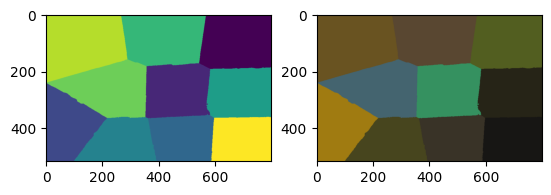

Text(0.5, 1.0, 'Superpixel Regions')

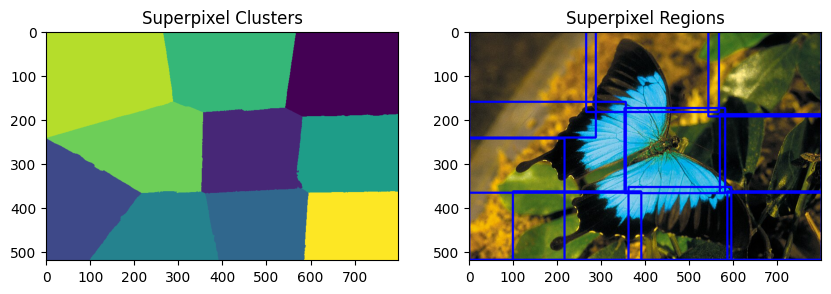

In [23]:
# Visualise your regions on the original image
#10 Superpixels
K = 10

loss, cluster_idx_image, quantised_image = kmean_colour(im, 10, K, False, 10)
corners = []

for k in range(K):
    #Extract the superpixel for the given K
    x, y = np.where(cluster_idx_image == k)
    top_left = x.min(), y.min()
    bottom_right = x.max(), y.max()
    corners.append((top_left, bottom_right))

# We will sketch the bounding rectangles on top of the original image, using the corners
regions_im = im.copy()
for tl, br in corners:
    cv2.rectangle(regions_im, tl[::-1], br[::-1], (255, 0, 0), 3)
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(cluster_idx_image)
plt.title('Superpixel Clusters')
plt.subplot(1,2,2)
plt.imshow(regions_im[:,:,[2,1,0]])
plt.title('Superpixel Regions')



## Task 4: Discussion

Write a brief report (max 600 words) discussing explaining your implementation
and results. Explain your reasoning by referencing the intermediate result figures
you generated.


Initially we used several for loops to run through each pixel and calculate the necessary attributes to solve for the k-mean. As soon as the spatial values were included this process started to balloon out of proportion. In task 2 going through 10 iterations took upwards of 15 minutes and only got worse as changes were made. To combat the computational needs of calculating each pixel one at a time we switched to vectorising the nested loops. To begin with we calculated the whole image at once instead of pixel by pixel. To do this we calculated the distance between each point and each centroid simultaneously and then filtered the list to use the minimum distance/value for each pixel, displaying the index. This was much faster than the old method which made use of nested for loops to run through each pixel individually calculating the distance from each centroid and then storing the shortest path to append to a list after checking each one.

To update the centroids we employed a boolean mask on the index list to get only the pixels closest to the current centroid being checked. The mean could be calculated from the list and the nearest pixel to the mean used as the new centroid. This process enabled us to skip a few steps like storing the values of each pixel and then taking the mean of them all which computationally was a lot more expensive.

When generating the images, we found the colour values were not actually being attributed to the expected rgb values and instead were bgr, needing the red and blue values swapped to display properly. Once that was established we found the value of spatial weight to have a drastically different outcome on the image. initially leaving spatial weight at 1 would allow for a fairly even split to colour and spatial impact on the superpixels but now a spatial weight of around 50 is required to balance their impact as can be seen in the images generated for part 2.